# Human Review Result Visualization

**Inputs:** Provide the path to the results directory; the script assumes all results are in the same directory, in a folder named `BASE/results/`. Update the data loading section to match your file names and file types (CSV/Excel).

In [ ]:
import pandas as pd
import numpy as np
import re
import os
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch
from scipy import stats

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

key_path = Path(r"XXX\KEY.csv")
review_path = Path(r"XXX\Article_2_human_eval.xlsx")
output_path = Path(r"XXX\figures\human_review_article_style_withpvalues.svg")
os.makedirs(output_path.parent, exist_ok=True)

In [2]:
def clean_colname(col):
    """Clean column names a bit."""
    col = str(col).strip()
    col = col.replace("\n", " ")
    col = re.sub(r"\s+", " ", col)
    return col

def normalize_question_folder(x):
    """
    Normalize question identifiers so review sheet and KEY.csv match.
    """
    if pd.isna(x):
        return np.nan
    x = str(x).strip().strip('"').strip("'")
    x = re.sub(r"\s+", "_", x)
    return x

def normalize_case_file(x):
    """
    Normalize case file names to style Case_1.md.
    """
    if pd.isna(x):
        return np.nan
    
    s = str(x).strip()
    
    # Numeric only
    if re.fullmatch(r"\d+", s):
        return f"Case_{int(s)}.md"
    
    # Case_1 or case_1
    m = re.fullmatch(r"(?i)case[_ ]?(\d+)(?:\.md)?", s)
    if m:
        return f"Case_{int(m.group(1))}.md"
    
    return s

def normalize_blind_model(x):
    """
    Normalize blinded model label in review sheet.
    """
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s == "":
        return np.nan
    if re.fullmatch(r"\d+", s):
        return str(int(s))
    return s.upper()

def load_review_file(path):
    """Load either xlsx or csv."""
    suffix = path.suffix.lower()
    if suffix in [".xlsx", ".xls"]:
        df = pd.read_excel(path)
    elif suffix == ".csv":
        df = pd.read_csv(path)
    else:
        raise ValueError(f"Unsupported review file type: {suffix}")
    return df

def extract_model_mapping_from_key(key_df):
    """
    From KEY.csv, create a long table:
    question_folder | case_file | blind_model | actual_model
    """
    model_cols = [
        c for c in key_df.columns
        if re.fullmatch(r"model_.+_actual_embedding_model", c)
    ]
    
    if not model_cols:
        raise ValueError(
            "No columns matching 'model_<label>_actual_embedding_model' were found in KEY.csv"
        )
    
    long_parts = []
    for c in model_cols:
        m = re.fullmatch(r"model_(.+)_actual_embedding_model", c)
        blind_label = m.group(1)
        
        tmp = key_df[["question_folder", "case_file", c]].copy()
        tmp = tmp.rename(columns={c: "actual_model"})
        tmp["blind_model"] = normalize_blind_model(blind_label)
        long_parts.append(tmp)
    
    long_df = pd.concat(long_parts, ignore_index=True)
    
    # Clean
    long_df["question_folder"] = long_df["question_folder"].map(normalize_question_folder)
    long_df["case_file"] = long_df["case_file"].map(normalize_case_file)
    long_df["blind_model"] = long_df["blind_model"].map(normalize_blind_model)
    
    return long_df

def prepare_key_dataframe(key_path):
    key = pd.read_csv(key_path)
    key.columns = [clean_colname(c) for c in key.columns]
    
    required_cols = ["question_folder", "case_file"]
    missing = [c for c in required_cols if c not in key.columns]
    if missing:
        raise ValueError(f"KEY.csv is missing required columns: {missing}")
    
    key["question_folder"] = key["question_folder"].map(normalize_question_folder)
    key["case_file"] = key["case_file"].map(normalize_case_file)
    
    model_map = extract_model_mapping_from_key(key)
    
    # Extra metadata from KEY.csv
    optional_cols = [
        "timestamp_utc",
        "question_text",
        "random_seed",
        "top_k",
        "splitter_size",
        "splitter_overlap",
        "md_path",
        "flow_embedding_model",
        "flow_embedding_model_1",
        "flow_embedding_model_2",
    ]
    existing_optional = [c for c in optional_cols if c in key.columns]
    
    key_meta = key[["question_folder", "case_file"] + existing_optional].drop_duplicates()
    
    return key, model_map, key_meta


In [3]:
def prepare_review_dataframe(review_path):
    review = load_review_file(review_path)
    review.columns = [clean_colname(c) for c in review.columns]
    
    print("Review columns:")
    print(list(review.columns))

    review = review.copy()
    
    if review.shape[1] < 4:
        raise ValueError("Review file seems to have too few columns.")
    
    renamed = {}
    cols = list(review.columns)
    renamed[cols[0]] = "question_folder"
    renamed[cols[1]] = "case_num"
    renamed[cols[2]] = "blind_model"
    renamed[cols[3]] = "text_chunk"
    
    review = review.rename(columns=renamed)
    
    # Normalize matching fields
    review["question_folder"] = review["question_folder"].map(normalize_question_folder)
    review["case_num"] = pd.to_numeric(review["case_num"], errors="coerce").astype("Int64")
    review["case_file"] = review["case_num"].map(lambda x: f"Case_{x}.md" if pd.notna(x) else np.nan)
    review["blind_model"] = review["blind_model"].map(normalize_blind_model)
    
    # Numeric cleanup
    possible_numeric = [
        "text_chunk",
        "Vastaako_kysymykseen_chunk (Kyllä/Ei)",
        "Vastausriittävyys (1-5)",
        "Vastaako_kysymykseen_whole (Kyllä/Ei)",
        "Vastausriittävyys (1-5).1",
        "Samat_tekstipätkät",
    ]
    for c in possible_numeric:
        if c in review.columns:
            review[c] = pd.to_numeric(review[c], errors="ignore")
    
    return review


In [4]:
key_raw, model_map, key_meta = prepare_key_dataframe(key_path)
review = prepare_review_dataframe(review_path)

print("KEY rows:", len(key_raw))
print("Model map rows:", len(model_map))
print("Review rows:", len(review))

Review columns:
['Case', 'Case.1', 'Malli', 'Text_chunk', 'chunk_answers_question', 'chunk_sufficiency', 'whole_answers_question', 'whole_sufficiency', 'same_whole_texts', 'other_info']
KEY rows: 60
Model map rows: 120
Review rows: 240


C:\Users\EXT16094453\AppData\Local\temp\28\ipykernel_16564\1758898773.py:39: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  review[c] = pd.to_numeric(review[c], errors="ignore")


In [5]:
dup_map = model_map.duplicated(subset=["question_folder", "case_file", "blind_model"], keep=False)
if dup_map.any():
    print("WARNING: duplicate mappings found in KEY.csv")
    display(model_map.loc[dup_map].sort_values(["question_folder", "case_file", "blind_model"]))
else:
    print("Model mapping is unique per question_folder + case_file + blind_model")

Model mapping is unique per question_folder + case_file + blind_model


In [6]:
merged = review.merge(
    model_map,
    on=["question_folder", "case_file", "blind_model"],
    how="left",
    validate="many_to_one"
)

# KEY metadata
merged = merged.merge(
    key_meta,
    on=["question_folder", "case_file"],
    how="left",
    validate="many_to_one"
)

print("Merged rows:", len(merged))

Merged rows: 240


In [7]:
unmatched = merged[merged["actual_model"].isna()].copy()

print(f"Unmatched review rows: {len(unmatched)}")

if len(unmatched) > 0:
    display(
        unmatched[
            ["question_folder", "case_num", "case_file", "blind_model"]
        ].drop_duplicates().sort_values(["question_folder", "case_num", "blind_model"])
    )

Unmatched review rows: 0


In [8]:
# Rename duplicate-like column
cols = list(merged.columns)

# If pandas imported "Vastausriittävyys (1-5)" as "... .1", rename it
if "Vastausriittävyys (1-5).1" in merged.columns:
    merged = merged.rename(columns={"Vastausriittävyys (1-5).1": "Vastausriittävyys_whole (1-5)"})
elif "Vastausriittävyys (1-5)" in merged.columns:
    # Only if there is no chunk version problems
    pass

if "Vastaako_kysymykseen_chunk (Kyllä/Ei)" in merged.columns:
    merged = merged.rename(columns={"Vastaako_kysymykseen_chunk (Kyllä/Ei)": "chunk_answers_question"})

if "Vastausriittävyys (1-5)" in merged.columns:
    merged = merged.rename(columns={"Vastausriittävyys (1-5)": "chunk_sufficiency"})

if "Vastaako_kysymykseen_whole (Kyllä/Ei)" in merged.columns:
    merged = merged.rename(columns={"Vastaako_kysymykseen_whole (Kyllä/Ei)": "whole_answers_question"})

if "Samat_tekstipätkät" in merged.columns:
    merged = merged.rename(columns={"Samat_tekstipätkät": "same_chunks_count"})

# Reorder
front_cols = [
    "question_folder",
    "case_num",
    "case_file",
    "blind_model",
    "actual_model",
    "text_chunk",
]
front_cols = [c for c in front_cols if c in merged.columns]

other_cols = [c for c in merged.columns if c not in front_cols]
merged = merged[front_cols + other_cols]

In [9]:
df = merged.copy()
chunk_case = (
    df.groupby(["question_folder", "case_num", "actual_model"])
    .agg(
        chunk_answer_rate = ("chunk_answers_question", "mean"),
        chunk_sufficiency_mean = ("chunk_sufficiency", "mean"),
        n_chunks = ("text_chunk", "count")
    )
    .reset_index()
)

chunk_case.head()


,question_folder,case_num,actual_model,chunk_answer_rate,chunk_sufficiency_mean,n_chunks
0,mik_on_potilaan_antitromboottinen_lkitys_asa_k...,1,multilingual-e5-large:f16,1.000000,3.000000,3
1,mik_on_potilaan_antitromboottinen_lkitys_asa_k...,1,qwen3-embedding:8b_q6_k,1.000000,3.000000,3
2,mik_on_potilaan_antitromboottinen_lkitys_asa_k...,2,multilingual-e5-large:f16,0.333333,0.666667,3
3,mik_on_potilaan_antitromboottinen_lkitys_asa_k...,2,qwen3-embedding:8b_q6_k,0.666667,1.000000,3
4,mik_on_potilaan_antitromboottinen_lkitys_asa_k...,3,multilingual-e5-large:f16,1.000000,4.333333,3


In [10]:
whole_case = (
    df.groupby(["question_folder", "case_num", "actual_model"])
    .agg(
        whole_answer = ("whole_answers_question", "max"),
        whole_sufficiency = ("whole_sufficiency", "max")
    )
    .reset_index()
)

whole_case.head()


,question_folder,case_num,actual_model,whole_answer,whole_sufficiency
0,mik_on_potilaan_antitromboottinen_lkitys_asa_k...,1,multilingual-e5-large:f16,1,3
1,mik_on_potilaan_antitromboottinen_lkitys_asa_k...,1,qwen3-embedding:8b_q6_k,1,3
2,mik_on_potilaan_antitromboottinen_lkitys_asa_k...,2,multilingual-e5-large:f16,1,5
3,mik_on_potilaan_antitromboottinen_lkitys_asa_k...,2,qwen3-embedding:8b_q6_k,1,5
4,mik_on_potilaan_antitromboottinen_lkitys_asa_k...,3,multilingual-e5-large:f16,1,5


In [11]:
def pivot_models(data, value_col):

    wide = (
        data.pivot_table(
            index=["question_folder", "case_num"],
            columns="actual_model",
            values=value_col
        )
        .reset_index()
    )

    wide.columns.name = None
    return wide

chunk_answer_wide = pivot_models(chunk_case, "chunk_answer_rate")
chunk_points_wide = pivot_models(chunk_case, "chunk_sufficiency_mean")

whole_answer_wide = pivot_models(whole_case, "whole_answer")
whole_points_wide = pivot_models(whole_case, "whole_sufficiency")


In [12]:
def model_preference(df_wide):

    model_cols = df_wide.columns[2:]

    m1, m2 = model_cols

    comp = df_wide.copy()

    comp["winner"] = np.select(
        [
            comp[m1] > comp[m2],
            comp[m2] > comp[m1]
        ],
        [m1, m2],
        default="tie"
    )

    summary = comp["winner"].value_counts()

    return comp, summary


In [13]:
chunk_ans_comp, chunk_ans_summary = model_preference(chunk_answer_wide)
chunk_ans_summary


winner
tie                          21
qwen3-embedding:8b_q6_k      12
multilingual-e5-large:f16     7
Name: count, dtype: int64

In [14]:
chunk_pts_comp, chunk_pts_summary = model_preference(chunk_points_wide)
chunk_pts_summary


winner
qwen3-embedding:8b_q6_k      21
multilingual-e5-large:f16    10
tie                           9
Name: count, dtype: int64

In [15]:
whole_ans_comp, whole_ans_summary = model_preference(whole_answer_wide)
whole_ans_summary


winner
tie                          33
qwen3-embedding:8b_q6_k       4
multilingual-e5-large:f16     3
Name: count, dtype: int64

In [16]:
whole_pts_comp, whole_pts_summary = model_preference(whole_points_wide)
whole_pts_summary


winner
tie                          27
qwen3-embedding:8b_q6_k       9
multilingual-e5-large:f16     4
Name: count, dtype: int64

In [17]:
import numpy as np
import pandas as pd
from scipy import stats

# Aggregate
binary_agg = (
    merged
    .groupby(['case_num', 'actual_model', 'question_folder'])
    .agg(
        chunk_answers=('chunk_answers_question', 'max'),
        chunk_sufficiency=('chunk_sufficiency', 'max'),
        whole_answers=('whole_answers_question', 'max'),
        whole_sufficiency=('whole_sufficiency', 'max')
    )
    .reset_index()
)

qwen = binary_agg[binary_agg['actual_model'].str.contains('qwen', case=False)]
e5   = binary_agg[binary_agg['actual_model'].str.contains('multilingual', case=False)]
paired = qwen.merge(e5, on=['case_num', 'question_folder'], suffixes=('_qwen', '_e5'))

# Bootstrap
def bootstrap_prob(diff, n_boot=10000, seed=42):
    rng = np.random.default_rng(seed)
    boot_means = [rng.choice(diff, size=len(diff), replace=True).mean()
                  for _ in range(n_boot)]
    lo, hi = np.percentile(boot_means, [2.5, 97.5])
    prob_qwen_better = np.mean(np.array(boot_means) > 0)
    return lo, hi, prob_qwen_better

# Tests
for question in paired['question_folder'].unique():
    q = paired[paired['question_folder'] == question]
    print(f"Question: {question}")

    # Binary: exact McNemar
    for col_q, col_e, label in [
        ('chunk_answers_qwen',  'chunk_answers_e5',  'Chunk'),
        ('whole_answers_qwen',  'whole_answers_e5',  'Whole note')
    ]:
        qwen_wins = (q[col_q] > q[col_e]).sum()
        e5_wins   = (q[col_e] > q[col_q]).sum()
        ties      = (q[col_q] == q[col_e]).sum()
        n_disc    = qwen_wins + e5_wins

        if n_disc > 0:
            res = stats.binomtest(int(qwen_wins), int(n_disc), p=0.5)
            p = res.pvalue
            ci_lo, ci_hi = res.proportion_ci(confidence_level=0.95)
            prob_qwen = qwen_wins / n_disc
        else:
            p, ci_lo, ci_hi, prob_qwen = 1.0, 0.0, 1.0, 0.5

        print(f"\n  {label} | answers question (binary)")
        print(f"    Qwen wins: {qwen_wins}, E5 wins: {e5_wins}, Ties: {ties}")
        print(f"    Exact McNemar: p = {p:.3f}")
        print(f"    P(Qwen wins | discordant) = {prob_qwen:.3f}, 95% CI [{ci_lo:.3f}, {ci_hi:.3f}]")

    # Ordinal: Wilcoxon + bootstrap
    for col_q, col_e, label in [
        ('chunk_sufficiency_qwen', 'chunk_sufficiency_e5', 'Chunk'),
        ('whole_sufficiency_qwen', 'whole_sufficiency_e5', 'Whole note')
    ]:
        qwen_s = q[col_q].values.astype(float)
        e5_s   = q[col_e].values.astype(float)
        diff   = qwen_s - e5_s

        if np.any(diff != 0):
            stat, p = stats.wilcoxon(qwen_s, e5_s, zero_method='wilcox', method='exact')
            n_nz = np.sum(diff != 0)
            r_rb = 1 - (2 * stat) / (n_nz * (n_nz + 1))
        else:
            stat, p, r_rb = np.nan, 1.0, 0.0

        lo, hi, prob_qwen = bootstrap_prob(diff)

        print(f"\n  {label} | sufficiency (0-5)")
        print(f"    Qwen3-8B:  mean={np.mean(qwen_s):.2f}, median={np.median(qwen_s):.1f}, "
              f"IQR={np.percentile(qwen_s,25):.1f}-{np.percentile(qwen_s,75):.1f}")
        print(f"    E5 Large:  mean={np.mean(e5_s):.2f}, median={np.median(e5_s):.1f}, "
              f"IQR={np.percentile(e5_s,25):.1f}-{np.percentile(e5_s,75):.1f}")
        print(f"    Wilcoxon (exact): W={stat}, p={p:.3f}, rank-biserial r={r_rb:.3f}")
        print(f"    Bootstrap: P(Qwen > E5) = {prob_qwen:.3f}, 95% CI on mean diff [{lo:.2f}, {hi:.2f}]")

Question: mik_on_potilaan_antitromboottinen_lkitys_asa_klopidogreeli_a

  Chunk | answers question (binary)
    Qwen wins: 3, E5 wins: 1, Ties: 16
    Exact McNemar: p = 0.625
    P(Qwen wins | discordant) = 0.750, 95% CI [0.194, 0.994]

  Whole note | answers question (binary)
    Qwen wins: 3, E5 wins: 1, Ties: 16
    Exact McNemar: p = 0.625
    P(Qwen wins | discordant) = 0.750, 95% CI [0.194, 0.994]

  Chunk | sufficiency (0-5)
    Qwen3-8B:  mean=4.30, median=5.0, IQR=4.5-5.0
    E5 Large:  mean=3.80, median=5.0, IQR=2.8-5.0
    Wilcoxon (exact): W=6.0, p=0.438, rank-biserial r=0.714
    Bootstrap: P(Qwen > E5) = 0.841, 95% CI on mean diff [-0.45, 1.45]

  Whole note | sufficiency (0-5)
    Qwen3-8B:  mean=4.65, median=5.0, IQR=5.0-5.0
    E5 Large:  mean=4.15, median=5.0, IQR=5.0-5.0
    Wilcoxon (exact): W=2.5, p=0.625, rank-biserial r=0.750
    Bootstrap: P(Qwen > E5) = 0.780, 95% CI on mean diff [-0.50, 1.50]
Question: mik_on_potilaan_keskeinen_verisuonikirurginen_sairaus_dia

In [18]:
summary = pd.DataFrame({

"Metric":[
"Chunk answer rate",
"Chunk sufficiency",
"Whole answer rate",
"Whole sufficiency"
],

"Model_A_mean":[
chunk_case.groupby("actual_model")["chunk_answer_rate"].mean()[0],
chunk_case.groupby("actual_model")["chunk_sufficiency_mean"].mean()[0],
whole_case.groupby("actual_model")["whole_answer"].mean()[0],
whole_case.groupby("actual_model")["whole_sufficiency"].mean()[0],
]

})

summary


C:\Users\EXT16094453\AppData\Local\temp\28\ipykernel_16564\2730827763.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  chunk_case.groupby("actual_model")["chunk_answer_rate"].mean()[0],
C:\Users\EXT16094453\AppData\Local\temp\28\ipykernel_16564\2730827763.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  chunk_case.groupby("actual_model")["chunk_sufficiency_mean"].mean()[0],
C:\Users\EXT16094453\AppData\Local\temp\28\ipykernel_16564\2730827763.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with Da

,Metric,Model_A_mean
0,Chunk answer rate,0.583333
1,Chunk sufficiency,2.158333
2,Whole answer rate,0.875000
3,Whole sufficiency,3.900000


In [19]:
df.groupby("question_folder")["same_whole_texts"].mean()

question_folder
mik_on_potilaan_antitromboottinen_lkitys_asa_klopidogreeli_a    1.300
mik_on_potilaan_keskeinen_verisuonikirurginen_sairaus_diagno    0.125
Name: same_whole_texts, dtype: float64

C:\Users\EXT16094453\AppData\Local\temp\28\ipykernel_16564\3118070332.py:144: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (qf, am, ml, el), subdf in plot_df.groupby(
C:\Users\EXT16094453\AppData\Local\temp\28\ipykernel_16564\3118070332.py:144: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (qf, am, ml, el), subdf in plot_df.groupby(


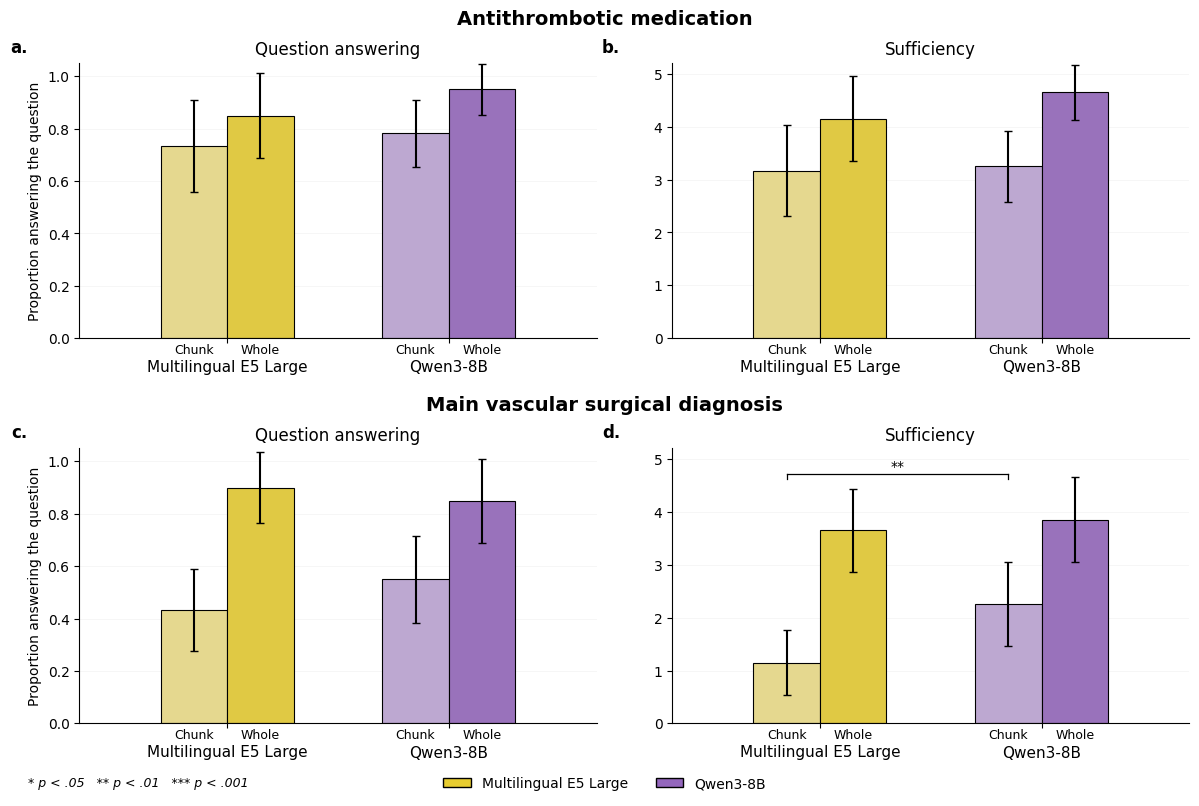

In [20]:
# Settings
question_order = [
    "mik_on_potilaan_antitromboottinen_lkitys_asa_klopidogreeli_a",
    "mik_on_potilaan_keskeinen_verisuonikirurginen_sairaus_diagno",
]
question_title_map = {
    "mik_on_potilaan_antitromboottinen_lkitys_asa_klopidogreeli_a": "Antithrombotic medication",
    "mik_on_potilaan_keskeinen_verisuonikirurginen_sairaus_diagno": "Main vascular surgical diagnosis",
}
model_order = ["multilingual-e5-large:f16", "qwen3-embedding:8b_q6_k"]
model_label_map = {
    "multilingual-e5-large:f16": "Multilingual E5 Large",
    "qwen3-embedding:8b_q6_k":   "Qwen3-8B",
}
base_model_colors = {
    "Multilingual E5 Large": "#E8CD31",
    "Qwen3-8B":               "#9467bd",
}
evaluation_levels = ["Chunk", "Whole text"]
metric_specs = [
    ("answer_metric",      "Question answering", "Proportion answering the question", (0, 1.05)),
    ("sufficiency_metric", "Sufficiency",         "Mean sufficiency score",             (0, 5.2)),
]
eval_to_alpha = {"Chunk": 0.45, "Whole text": 0.00}
 
# Colors
def shade(color, mix_with=(0.92, 0.92, 0.92), alpha=0.0):
    base = np.array(to_rgb(color))
    grey = np.array([0.7, 0.7, 0.7])
    mix  = np.array(mix_with)
    base = 0.85 * base + 0.15 * grey
    return tuple((1 - alpha) * base + alpha * mix)

# Significance: p -> stars, None if ns
def p_to_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return None  # not significant
 
def compute_significance(merged):
    sig = {}
 
    qwen   = merged[merged["actual_model"].str.contains("qwen",         case=False)]
    e5     = merged[merged["actual_model"].str.contains("multilingual",  case=False)]
    paired = qwen.merge(e5, on=["case_num", "question_folder"],
                        suffixes=("_qwen", "_e5"))
 
    for question in paired["question_folder"].unique():
        q = paired[paired["question_folder"] == question]
 
        # Binary answer metrics, exact McNemar via binomtest
        for col_q, col_e, eval_level, metric_key in [
            ("chunk_answers_question_qwen",  "chunk_answers_question_e5",  "Chunk",      "answer_metric"),
            ("whole_answers_question_qwen",  "whole_answers_question_e5",  "Whole text", "answer_metric"),
        ]:
            if col_q not in q.columns or col_e not in q.columns:
                continue
            qwen_wins = (q[col_q] > q[col_e]).sum()
            e5_wins   = (q[col_e] > q[col_q]).sum()
            n_disc    = qwen_wins + e5_wins
            p = stats.binomtest(int(qwen_wins), int(n_disc), p=0.5).pvalue \
                if n_disc > 0 else 1.0
            stars = p_to_stars(p)
            if stars is not None:
                sig[(question, metric_key, eval_level)] = (stars, p)
 
        # Ordinal sufficiency, Wilcoxon signed-rank exact
        for col_q, col_e, eval_level, metric_key in [
            ("chunk_sufficiency_qwen",  "chunk_sufficiency_e5",  "Chunk",      "sufficiency_metric"),
            ("whole_sufficiency_qwen",  "whole_sufficiency_e5",  "Whole text", "sufficiency_metric"),
        ]:
            if col_q not in q.columns or col_e not in q.columns:
                continue
            qwen_s = q[col_q].values.astype(float)
            e5_s   = q[col_e].values.astype(float)
            diff   = qwen_s - e5_s
            if np.any(diff != 0):
                stat, p = stats.wilcoxon(qwen_s, e5_s,
                                         zero_method="wilcox", method="exact")
            else:
                p = 1.0
            stars = p_to_stars(p)
            if stars is not None:
                sig[(question, metric_key, eval_level)] = (stars, p)
 
    return sig
 
# Data helpers
def make_case_level_tables(df_subset):
    chunk_case = (
        df_subset.groupby(["question_folder", "case_num", "actual_model"], dropna=False)
        .agg(
            chunk_answers_question=("chunk_answers_question", "mean"),
            chunk_sufficiency=("chunk_sufficiency", "mean"),
            n_chunks=("text_chunk", "count"),
        )
        .reset_index()
    )
    whole_case = (
        df_subset.groupby(["question_folder", "case_num", "actual_model"], dropna=False)
        .agg(
            whole_answers_question=("whole_answers_question", "max"),
            whole_sufficiency=("whole_sufficiency", "max"),
        )
        .reset_index()
    )
    return chunk_case, whole_case
 
 
def build_plot_df(df_subset):
    chunk_case, whole_case = make_case_level_tables(df_subset)
 
    chunk_plot = chunk_case.copy()
    chunk_plot["evaluation_level"]   = "Chunk"
    chunk_plot["answer_metric"]      = chunk_plot["chunk_answers_question"]
    chunk_plot["sufficiency_metric"] = chunk_plot["chunk_sufficiency"]
 
    whole_plot = whole_case.copy()
    whole_plot["evaluation_level"]   = "Whole text"
    whole_plot["answer_metric"]      = whole_plot["whole_answers_question"]
    whole_plot["sufficiency_metric"] = whole_plot["whole_sufficiency"]
 
    cols = ["question_folder", "case_num", "actual_model",
            "evaluation_level", "answer_metric", "sufficiency_metric"]
    plot_df = pd.concat([chunk_plot[cols], whole_plot[cols]], ignore_index=True)
    plot_df["actual_model"]    = pd.Categorical(plot_df["actual_model"],
                                                categories=model_order, ordered=True)
    plot_df["evaluation_level"] = pd.Categorical(plot_df["evaluation_level"],
                                                  categories=evaluation_levels, ordered=True)
    plot_df["model_label"] = plot_df["actual_model"].map(model_label_map)
    return plot_df
 
 
def mean_ci95(series):
    s = pd.Series(series).dropna()
    n = len(s)
    if n == 0: return np.nan, np.nan
    if n == 1: return float(s.mean()), 0.0
    return float(s.mean()), 1.96 * float(s.std(ddof=1) / np.sqrt(n))
 
def summarise_metric(plot_df, value_col):
    rows = []
    for (qf, am, ml, el), subdf in plot_df.groupby(
            ["question_folder", "actual_model", "model_label", "evaluation_level"],
            dropna=False):
        mean, ci = mean_ci95(subdf[value_col])
        rows.append({"question_folder": qf, "actual_model": am,
                     "model_label": ml, "evaluation_level": el,
                     "mean": mean, "ci": ci})
    return pd.DataFrame(rows)
 

# Significance bracket 
def add_significance_bracket(ax, x1, x2, y_top, stars,
                              fontsize=9, lw=0.9, color="black",
                              gap=0.08, tick_h=0.06):
    y_base = y_top + gap          # Bottom of vertical ticks
    y_line = y_base + tick_h      # Height of horizontal connecting bar
 
    # Left tick
    ax.plot([x1, x1], [y_base, y_line], color=color, lw=lw, clip_on=False)
    # Right tick
    ax.plot([x2, x2], [y_base, y_line], color=color, lw=lw, clip_on=False)
    # Horizontal bar
    ax.plot([x1, x2], [y_line, y_line], color=color, lw=lw, clip_on=False)
    # Stars
    ax.text((x1 + x2) / 2, y_line, stars,
            ha="center", va="bottom",
            fontsize=fontsize, color=color)
 
    return y_line  # Highest point reached
 
# Prep
plot_df    = build_plot_df(df)
chunk_case, whole_case = make_case_level_tables(df)
 
merged_for_tests = chunk_case.merge(
    whole_case[["question_folder", "case_num", "actual_model",
                "whole_answers_question", "whole_sufficiency"]],
    on=["question_folder", "case_num", "actual_model"],
    how="left",
)
significance_map = compute_significance(merged_for_tests)
 
summary_answer              = summarise_metric(plot_df, "answer_metric")
summary_answer["metric_type"] = "Question answering"
summary_suff                = summarise_metric(plot_df, "sufficiency_metric")
summary_suff["metric_type"]   = "Sufficiency"
summary_df = pd.concat([summary_answer, summary_suff], ignore_index=True)
 
# Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=False)
 
bar_width    = 0.18
x            = np.array([-0.3, 0.3])
offsets      = {"Chunk": -bar_width / 2, "Whole text": +bar_width / 2}
panel_labels = ["a.", "b.", "c.", "d."]
panel_i      = 0
 
# Gap/tick sizes per metric 
bracket_params = {
    "Question answering": {"gap": 0.04, "tick_h": 0.03},
    "Sufficiency":        {"gap": 0.12, "tick_h": 0.10},
}

for r, question in enumerate(question_order):
    for c, (metric_key, metric_title, ylab, ylim) in enumerate(metric_specs):
        ax = axes[r, c]
 
        metric_subset = summary_df[
            (summary_df["question_folder"] == question) &
            (summary_df["metric_type"]     == metric_title)
        ].copy()
 
        bar_top  = {}
        x_centre = {}
        means_all, cis_all, colors, x_positions = [], [], [], []
 
        for i, model in enumerate(model_order):
            ml = model_label_map[model]
            for el in evaluation_levels:
                row = metric_subset[
                    (metric_subset["actual_model"]    == model) &
                    (metric_subset["evaluation_level"] == el)
                ]
                m, ci = (float(row["mean"].iloc[0]), float(row["ci"].iloc[0])) \
                        if len(row) == 1 else (np.nan, 0.0)
 
                means_all.append(m)
                cis_all.append(ci)
                colors.append(shade(base_model_colors[ml], alpha=eval_to_alpha[el]))
                xp = x[i] + offsets[el]
                x_positions.append(xp)
                x_centre[(ml, el)] = xp
                if not np.isnan(m):
                    bar_top[(ml, el)] = m + ci
 
        ax.bar(x_positions, means_all, yerr=cis_all,
               width=bar_width, capsize=3, linewidth=0.8,
               edgecolor="black", color=colors)
 
        # Significance brackets (only where p < 0.05)
        bp = bracket_params[metric_title]
        needed_ylim = ylim[1]
 
        for el in evaluation_levels:
            entry = significance_map.get((question, metric_key, el))
            if entry is None:
                continue
            stars, _ = entry
 
            x1 = x_centre.get(("Multilingual E5 Large", el))
            x2 = x_centre.get(("Qwen3-8B", el))
            if x1 is None or x2 is None:
                continue
 
            y_top = max(
                bar_top.get(("Multilingual E5 Large", el), 0),
                bar_top.get(("Qwen3-8B", el), 0),
            )
            if metric_title == "Sufficiency":
                y_top = max(y_top, 4.50) # Height of the * bracket
            y_reached = add_significance_bracket(
                ax, x1, x2, y_top, stars,
                fontsize=10, lw=0.9,
                gap=bp["gap"], tick_h=bp["tick_h"],
            )
            # ylim to fit bracket + stars + a little headroom
            needed_ylim = max(needed_ylim, y_reached + bp["tick_h"] * 3)
 
        # Axes formatting
        ax.set_title(metric_title, fontsize=12)
        ax.set_xticks(x)
        ax.set_xticklabels([model_label_map[m] for m in model_order],
                           rotation=0, ha="center", fontsize=11)
        ax.tick_params(axis="x", pad=12)
        ax.set_xlim(-0.7, 0.7)
        ax.set_ylabel(ylab if c == 0 else "", fontsize=10)
        ax.set_xlabel("")
 
        if metric_title == "Question answering":
            ax.set_ylim(0, max(ylim[1], needed_ylim))
            ax.set_yticks(np.linspace(0, 1, 6))
        else:
            ax.set_ylim(0, max(ylim[1], needed_ylim))
            ax.set_yticks(np.arange(0, 6, 1))
 
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="y", linewidth=0.4, alpha=0.2)
        ax.grid(axis="x", visible=False)
        ax.set_axisbelow(True)
 
        for el in evaluation_levels:
            lbl = "Chunk" if el == "Chunk" else "Whole"
            for i in range(len(model_order)):
                ax.text(x[i] + offsets[el], -0.02, lbl,
                        transform=ax.get_xaxis_transform(),
                        ha="center", va="top", fontsize=9)
 
        ax.text(-0.10, 1.04, panel_labels[panel_i],
                transform=ax.transAxes, fontsize=12,
                fontweight="bold", ha="right")
        panel_i += 1
 
# Legend + titles
model_handles = [
    Patch(facecolor=base_model_colors["Multilingual E5 Large"],
          edgecolor="black", label="Multilingual E5 Large"),
    Patch(facecolor=base_model_colors["Qwen3-8B"],
          edgecolor="black", label="Qwen3-8B"),
]
fig.legend(handles=model_handles, loc="lower center", ncol=4,
           frameon=False, bbox_to_anchor=(0.5, -0.005))
 
fig.text(0.5, 0.975, "Antithrombotic medication",
         ha="center", va="center", fontsize=14, fontweight="bold")
fig.text(0.5, 0.492, "Main vascular surgical diagnosis",
         ha="center", va="center", fontsize=14, fontweight="bold")
 
# Significance legend at bottom left
if significance_map:
    fig.text(0.02, 0.012,
             "* p < .05   ** p < .01   *** p < .001",
             ha="left", va="bottom", fontsize=9, style="italic")
 
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.subplots_adjust(hspace=0.40)
fig.savefig(
    output_path,
    format="svg",
    dpi=300,
    bbox_inches="tight",
)
plt.show()